### Metalabelling testing

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import pandas_ta as ta


In [25]:
PRIMARY_THRESHOLD = 0.55
META_THRESHOLD = 0.55
META_TRAIN_FRAC = 0.30

CSV_PATH = "EURUSD_Candlestick_5_M_ASK_30.09.2019-30.09.2022.csv"

N_ROWS = 30000

BARS = 20
D_FRAC = 0.3
SLCOEF = 1.0
TPSL_RATIO = 1.0

TRAIN_SIZE = 5000
TEST_SIZE = 2500
EMBARGO = BARS

PRIMARY_THRESHOLD = 0.55
META_THRESHOLD = 0.55
META_TRAIN_FRAC = 0.30

MAX_ATR_RANK = 0.80
MIN_TREND_STRENGTH = 0.50
MAX_VOL_RATIO = 1.80
USE_VOL_RATIO_FILTER = True

In [26]:
# =========================
# LOAD DATA
# =========================

df = pd.read_csv(CSV_PATH)
df = df.loc[:N_ROWS].copy().reset_index(drop=True)

for col in ["Open", "High", "Low", "Close", "Volume"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["Open", "High", "Low", "Close"]).reset_index(drop=True)

In [27]:

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Long", "Long"],
        yticklabels=["No Long", "Long"],
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

    print(title)
    print(classification_report(y_true, y_pred, zero_division=0))


def walk_forward_pca_metalabel(
    df_model,
    feature_cols,
    target_col,
    train_size=5000,
    test_size=2500,
    embargo=20,
):
    all_rows = []
    fold_reports = []

    n = len(df_model)
    fold = 0

    for start in range(0, n - train_size - embargo - test_size + 1, test_size):
        fold += 1

        train_start = start
        train_end = start + train_size

        test_start = train_end + embargo
        test_end = test_start + test_size

        train_df = df_model.iloc[train_start:train_end].copy()
        test_df = df_model.iloc[test_start:test_end].copy()

        # split training into primary-train and meta-train
        split_idx = int(len(train_df) * (1 - META_TRAIN_FRAC))

        primary_train_df = train_df.iloc[:split_idx].copy()
        meta_train_df = train_df.iloc[split_idx:].copy()

        X_primary = primary_train_df[feature_cols]
        y_primary = primary_train_df[target_col].astype(int)

        X_meta_raw = meta_train_df[feature_cols]
        y_meta_true = meta_train_df[target_col].astype(int)

        X_test_raw = test_df[feature_cols]
        y_test = test_df[target_col].astype(int)

        if y_primary.nunique() < 2 or y_test.nunique() < 2:
            print(f"Fold {fold}: skipped one-class train/test.")
            continue

        # ======================
        # PCA preprocessing
        # ======================
        scaler = StandardScaler()
        pca = PCA(n_components=None)

        X_primary_scaled = scaler.fit_transform(X_primary)
        X_primary_pca = pca.fit_transform(X_primary_scaled)

        X_meta_pca = pca.transform(scaler.transform(X_meta_raw))
        X_test_pca = pca.transform(scaler.transform(X_test_raw))

        pca_cols = [f"PC{i+1}" for i in range(X_primary_pca.shape[1])]

        X_primary_pca = pd.DataFrame(X_primary_pca, columns=pca_cols)
        X_meta_pca = pd.DataFrame(X_meta_pca, columns=pca_cols)
        X_test_pca = pd.DataFrame(X_test_pca, columns=pca_cols)

        # ======================
        # Primary XGBoost model
        # ======================
        primary_model = xgb.XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=30,
            n_jobs=-1,
        )

        primary_model.fit(X_primary_pca, y_primary)

        meta_primary_proba = primary_model.predict_proba(X_meta_pca)[:, 1]
        test_primary_proba = primary_model.predict_proba(X_test_pca)[:, 1]

        meta_primary_signal = (meta_primary_proba >= PRIMARY_THRESHOLD).astype(int)
        test_primary_signal = (test_primary_proba >= PRIMARY_THRESHOLD).astype(int)

        # ======================
        # Meta-labeling
        # Only train meta-model on trades proposed by primary model
        # ======================
        meta_candidates = meta_primary_signal == 1

        if meta_candidates.sum() < 20 or y_meta_true[meta_candidates].nunique() < 2:
            print(f"Fold {fold}: meta-model skipped, not enough valid meta-label data.")
            test_meta_signal = test_primary_signal.copy()
            meta_used = False

        else:
            X_meta_train = X_meta_pca.loc[meta_candidates].copy()
            X_meta_train["primary_proba"] = meta_primary_proba[meta_candidates]

            y_meta_label = y_meta_true.loc[meta_candidates].astype(int)

            meta_model = xgb.XGBClassifier(
                n_estimators=200,
                max_depth=2,
                learning_rate=0.03,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=31,
                n_jobs=-1,
            )

            meta_model.fit(X_meta_train, y_meta_label)

            test_candidates = test_primary_signal == 1

            test_meta_signal = np.zeros_like(test_primary_signal)

            if test_candidates.sum() > 0:
                X_test_meta = X_test_pca.loc[test_candidates].copy()
                X_test_meta["primary_proba"] = test_primary_proba[test_candidates]

                test_meta_proba = meta_model.predict_proba(X_test_meta)[:, 1]

                accepted = test_meta_proba >= META_THRESHOLD

                candidate_indices = np.where(test_candidates)[0]
                accepted_indices = candidate_indices[accepted]

                test_meta_signal[accepted_indices] = 1

            meta_used = True

        fold_df = pd.DataFrame({
            "fold": fold,
            "y_true": y_test.values,
            "primary_proba": test_primary_proba,
            "primary_signal": test_primary_signal,
            "meta_signal": test_meta_signal,
            "meta_used": meta_used,
        })

        all_rows.append(fold_df)

        fold_reports.append({
            "fold": fold,
            "primary_signals": int(test_primary_signal.sum()),
            "meta_signals": int(test_meta_signal.sum()),
            "meta_used": meta_used,
            "pca_components": X_primary_pca.shape[1],
            "pca_explained_variance_total": pca.explained_variance_ratio_.sum(),
        })

    return pd.concat(all_rows, ignore_index=True), pd.DataFrame(fold_reports)

In [28]:
# =========================
# FRACTIONAL DIFFERENCING
# =========================

def get_weights(d, size):
    w = [1.0]
    for k in range(1, size):
        w_ = -w[-1] * (d - k + 1) / k
        w.append(w_)
    return np.array(w[::-1])


def frac_diff(series, d=0.3, thresh=1e-5):
    T = len(series)
    weights = get_weights(d, T)
    weights = weights[np.abs(weights) > thresh]
    width = len(weights)

    output = pd.Series(index=series.index, dtype="float64")

    for i in tqdm(range(width, T), desc="Frac diff"):
        window = series.iloc[i-width:i]
        output.iloc[i] = np.dot(weights, window)

    return output


In [29]:
# =========================
# RAW-PRICE LONG LABELING
# =========================

def atr_label_threshold_long(df, bars=20, d=0.3, slcoef=1.0, TPSLRatio=1.0):
    df = df.copy()

    df["ATR"] = ta.atr(df["High"], df["Low"], df["Close"], length=14)

    tpcoef = slcoef * TPSLRatio
    lower = df["Close"] - slcoef * df["ATR"]
    upper = df["Close"] + tpcoef * df["ATR"]

    df = df.reset_index(drop=True)
    lower = lower.reset_index(drop=True)
    upper = upper.reset_index(drop=True)

    df["Label_Long"] = 0

    for i in tqdm(range(len(df) - bars), desc="Long labels"):
        future_close = df["Close"].iloc[i+1:i+bars+1]

        tp_hit = (future_close >= upper.iloc[i]).any()
        sl_not_hit = (future_close > lower.iloc[i]).all()

        if tp_hit and sl_not_hit:
            df.loc[i, "Label_Long"] = 1

    df["Close_fd"] = frac_diff(df["Close"], d=d)

    return df

df = atr_label_threshold_long(
    df,
    bars=BARS,
    d=D_FRAC,
    slcoef=SLCOEF,
    TPSLRatio=TPSL_RATIO,
)

df[["Close", "ATR", "Close_fd", "Label_Long"]].head()

# =========================
# FEATURE ENGINEERING
# =========================

# Raw EMAs
df["EMA30"] = df["Close"].ewm(span=30, adjust=False).mean()
df["EMA50"] = df["Close"].ewm(span=50, adjust=False).mean()
df["EMA100"] = df["Close"].ewm(span=100, adjust=False).mean()

# Frac-diff EMAs
df["EMA_fd_30"] = df["Close_fd"].ewm(span=30, adjust=False).mean()
df["EMA50_fd"] = df["Close_fd"].ewm(span=50, adjust=False).mean()
df["EMA100_fd"] = df["Close_fd"].ewm(span=100, adjust=False).mean()

# RSI
df["RSI_raw"] = ta.rsi(df["Close"], length=14)
df["RSI_fd"] = ta.rsi(df["Close_fd"], length=14)

# Distance to EMA
df["dist_ema30_raw_norm"] = (df["Close"] - df["EMA30"]) / df["ATR"]
df["dist_ema30_fd_norm"] = (df["Close_fd"] - df["EMA_fd_30"]) / df["ATR"]

# Slopes
df["ema30_slope_raw_norm"] = df["EMA30"].diff(3) / df["ATR"]
df["ema30_slope_fd"] = df["EMA_fd_30"].diff(3)
df["ema30_acc_fd"] = df["ema30_slope_fd"].diff()

# EMA ordering
df["ema_position_raw"] = np.where(
    (df["EMA30"] > df["EMA50"]) & (df["EMA50"] > df["EMA100"]),
    1,
    np.where(
        (df["EMA30"] < df["EMA50"]) & (df["EMA50"] < df["EMA100"]),
        -1,
        0,
    ),
)

df["ema_position_fd"] = np.where(
    (df["EMA_fd_30"] > df["EMA50_fd"]) & (df["EMA50_fd"] > df["EMA100_fd"]),
    1,
    np.where(
        (df["EMA_fd_30"] < df["EMA50_fd"]) & (df["EMA50_fd"] < df["EMA100_fd"]),
        -1,
        0,
    ),
)

df["ema_spread_fd"] = (
    (df["EMA_fd_30"] - df["EMA50_fd"])
    + (df["EMA50_fd"] - df["EMA100_fd"])
)

Frac diff: 100%|██████████| 27726/27726 [00:00<00:00, 37051.15it/s]


In [31]:
# =========================
# CREATE MODEL DATAFRAME
# =========================

feature_cols = [
    "ATR",
    "RSI_raw",
    "RSI_fd",
    "Close_fd",
    "EMA_fd_30",
    "EMA50_fd",
    "EMA100_fd",
    "dist_ema30_raw_norm",
    "dist_ema30_fd_norm",
    "ema30_slope_raw_norm",
    "ema30_slope_fd",
    "ema30_acc_fd",
    "ema_position_raw",
    "ema_position_fd",
    "ema_spread_fd",
]

target_col = "Label_Long"

df_model = df[
    feature_cols
    + [
        target_col,
        "Open",
        "High",
        "Low",
        "Close",
        "Volume",
    ]
].copy()

df_model = df_model.replace([np.inf, -np.inf], np.nan)
df_model = df_model.dropna().reset_index(drop=True)

print("df_model shape:", df_model.shape)
print("\nLabel distribution:")
print(df_model[target_col].value_counts())
print("\nBase rate:")
print(df_model[target_col].mean())

display(df_model.head())

df_model shape: (27722, 21)

Label distribution:
Label_Long
0    18465
1     9257
Name: count, dtype: int64

Base rate:
0.3339225164129572


,ATR,RSI_raw,RSI_fd,Close_fd,EMA_fd_30,EMA50_fd,EMA100_fd,dist_ema30_raw_norm,dist_ema30_fd_norm,ema30_slope_raw_norm,...,ema30_acc_fd,ema_position_raw,ema_position_fd,ema_spread_fd,Label_Long,Open,High,Low,Close,Volume
0,0.000186,51.326358,15.904325,0.083259,0.083303,0.083312,0.083319,0.197545,-0.236302,-0.008798,...,9.734360e-07,-1,-1,-0.000015,1,1.09741,1.09741,1.09730,1.09741,212.350
1,0.000184,51.961356,16.276916,0.083264,0.083301,0.083310,0.083318,0.288478,-0.201969,0.040854,...,-6.975568e-08,-1,-1,-0.000017,1,1.09738,1.09751,1.09735,1.09743,125.955
2,0.000184,53.904236,17.317875,0.083275,0.083299,0.083309,0.083317,0.573994,-0.132457,0.073158,...,1.149117e-05,-1,-1,-0.000018,1,1.09742,1.09759,1.09740,1.09749,212.060
3,0.000175,53.515755,22.119346,0.083325,0.083301,0.083309,0.083317,0.512851,0.141385,0.098064,...,4.725825e-06,-1,-1,-0.000016,1,1.09749,1.09749,1.09744,1.09748,49.560
4,0.000172,54.915407,21.283790,0.083294,0.083300,0.083309,0.083316,0.704068,-0.039096,0.126791,...,2.094820e-06,-1,-1,-0.000016,1,1.09747,1.09756,1.09742,1.09752,194.060


In [32]:
ml_pca_meta_results, pca_meta_diagnostics = walk_forward_pca_metalabel(
    df_model=df_model,
    feature_cols=feature_cols,
    target_col=target_col,
    train_size=TRAIN_SIZE,
    test_size=TEST_SIZE,
    embargo=EMBARGO,
)

display(pca_meta_diagnostics)
display(ml_pca_meta_results.head())

,fold,primary_signals,meta_signals,meta_used,pca_components,pca_explained_variance_total
0,1,598,361,True,15,1.0
1,2,126,19,True,15,1.0
2,3,28,14,True,15,1.0
3,4,193,27,True,15,1.0
4,5,84,10,True,15,1.0
5,6,130,3,True,15,1.0
6,7,134,88,True,15,1.0
7,8,281,80,True,15,1.0
8,9,688,37,True,15,1.0


,fold,y_true,primary_proba,primary_signal,meta_signal,meta_used
0,1,1,0.173137,0,0,True
1,1,1,0.293867,0,0,True
2,1,1,0.228590,0,0,True
3,1,0,0.236511,0,0,True
4,1,0,0.233658,0,0,True


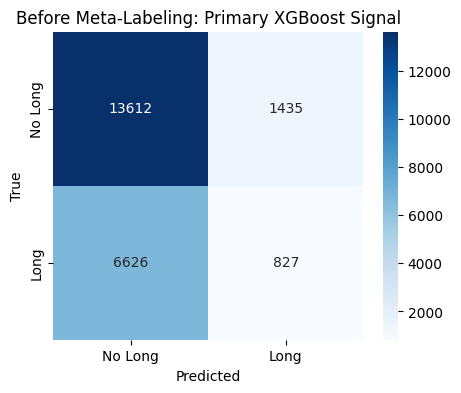

Before Meta-Labeling: Primary XGBoost Signal
              precision    recall  f1-score   support

           0       0.67      0.90      0.77     15047
           1       0.37      0.11      0.17      7453

    accuracy                           0.64     22500
   macro avg       0.52      0.51      0.47     22500
weighted avg       0.57      0.64      0.57     22500



In [33]:
plot_cm(
    ml_pca_meta_results["y_true"],
    ml_pca_meta_results["primary_signal"],
    "Before Meta-Labeling: Primary XGBoost Signal"
)

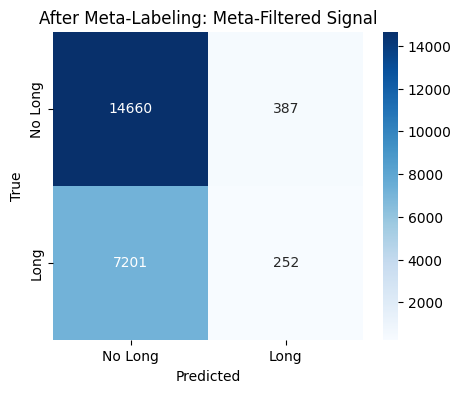

After Meta-Labeling: Meta-Filtered Signal
              precision    recall  f1-score   support

           0       0.67      0.97      0.79     15047
           1       0.39      0.03      0.06      7453

    accuracy                           0.66     22500
   macro avg       0.53      0.50      0.43     22500
weighted avg       0.58      0.66      0.55     22500



In [34]:
plot_cm(
    ml_pca_meta_results["y_true"],
    ml_pca_meta_results["meta_signal"],
    "After Meta-Labeling: Meta-Filtered Signal"
)